### Attrition in an Organization || Why Workers Quit?
**Employees** are the backbone of the organization. Organization's performance is heavily based on the quality of the employees. Challenges that an organization has to face due employee attrition are:

> 1. Expensive in terms of both money and time to train new employees.
> 2. Loss of experienced employees
> 3. Impact in productivity
> 4. Impact profit

Before getting our hands dirty with the data, first step is to frame the business question. Having clarity on below questions is very crucial because the solution that is being developed will make sense only if we have well stated problem.

---

### 📌 Business questions to brainstorm:
1. What factors are contributing more to employee attrition?
2. What type of measures should the company take in order to retain their employees?
3. What business value does the model bring?
4. Will the model save lots of money?
5. Which business unit faces the attrition problem?

In [2]:
import hvplot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hvplot.pandas

In [3]:
%matplotlib inline
sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")

pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)

In [4]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## EDA

- Find patterns in data through data visualization. Reveal hidden secrets of data through graphs, analysis and charts.
- Detect Outliers
- Feature engineering

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.00,1024.87,2.72,65.89,2.73,2.06,2.73,6502.93,14313.10,2.69,15.21,3.15,2.71,80.00,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.00,602.02,1.09,20.33,0.71,1.11,1.10,4707.96,7117.79,2.50,3.66,0.36,1.08,0.00,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.00,1.00,1.00,30.00,1.00,1.00,1.00,1009.00,2094.00,0.00,11.00,3.00,1.00,80.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.00,491.25,2.00,48.00,2.00,1.00,2.00,2911.00,8047.00,1.00,12.00,3.00,2.00,80.00,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.00,1020.50,3.00,66.00,3.00,2.00,3.00,4919.00,14235.50,2.00,14.00,3.00,3.00,80.00,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.00,1555.75,4.00,83.75,3.00,3.00,4.00,8379.00,20461.50,4.00,18.00,3.00,4.00,80.00,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.00,2068.00,4.00,100.00,4.00,5.00,4.00,19999.00,26999.00,9.00,25.00,4.00,4.00,80.00,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


In [7]:
for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")
    print("-----------------------")

Age: 43 unique values
-----------------------
Attrition: 2 unique values
-----------------------
BusinessTravel: 3 unique values
-----------------------
DailyRate: 886 unique values
-----------------------
Department: 3 unique values
-----------------------
DistanceFromHome: 29 unique values
-----------------------
Education: 5 unique values
-----------------------
EducationField: 6 unique values
-----------------------
EmployeeCount: 1 unique values
-----------------------
EmployeeNumber: 1470 unique values
-----------------------
EnvironmentSatisfaction: 4 unique values
-----------------------
Gender: 2 unique values
-----------------------
HourlyRate: 71 unique values
-----------------------
JobInvolvement: 4 unique values
-----------------------
JobLevel: 5 unique values
-----------------------
JobRole: 9 unique values
-----------------------
JobSatisfaction: 4 unique values
-----------------------
MaritalStatus: 3 unique values
-----------------------
MonthlyIncome: 1349 unique va

We notice that `EmployeeCount`, `Over18`, `StandardHours` have only one unique values and `EmployeeNumber` has 1470 unique values. This features aren't useful for us, So we are going to drop those columns.

In [8]:
df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis="columns", inplace=True)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


### Categorical Features

In [9]:
object_col = []
for column in df.columns:
    if df[column].dtype == "object" and len(df[column].unique()) <= 30: 
        # why: len(df[column].unique()) <= 30 :::✅ 类别变量：Education Level（5种）、Job Role（10种）； ❌ 高基数变量：Employee Name（每人不同，可能上千个）
        object_col.append(column)
        print(f"{column}: {df[column].unique()} unique values")
        print(df[column].value_counts())
        print("-----------------------")
object_col.remove("Attrition")

Attrition: ['Yes' 'No'] unique values
Attrition
No     1233
Yes     237
Name: count, dtype: int64
-----------------------
BusinessTravel: ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel'] unique values
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
-----------------------
Department: ['Sales' 'Research & Development' 'Human Resources'] unique values
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64
-----------------------
EducationField: ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources'] unique values
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64
-----------------------
Gender: ['Female' 'Male'] unique values
Gender
Male      882
Female    588
Name: count, dtype: int6

In [10]:
len(object_col)

7

In [11]:
from sklearn.preprocessing import LabelEncoder

label = LabelEncoder()
df["Attrition"] = label.fit_transform(df.Attrition)

### Numerical Features

In [12]:
disc_col = []
for column in df.columns:
    if df[column].dtype != "object" and len(df[column].unique()) <= 30: 
        # why: len(df[column].unique()) <= 30 :::✅ 类别变量：Education Level（5种）、Job Role（10种）； ❌ 高基数变量：Employee Name（每人不同，可能上千个）
        disc_col.append(column)
        print(f"{column}: {df[column].unique()} unique values")
        print("-----------------------")
disc_col.remove("Attrition")

Attrition: [1 0] unique values
-----------------------
DistanceFromHome: [ 1  8  2  3 24 23 27 16 15 26 19 21  5 11  9  7  6 10  4 25 12 18 29 22
 14 20 28 17 13] unique values
-----------------------
Education: [2 1 4 3 5] unique values
-----------------------
EnvironmentSatisfaction: [2 3 4 1] unique values
-----------------------
JobInvolvement: [3 2 4 1] unique values
-----------------------
JobLevel: [2 1 3 4 5] unique values
-----------------------
JobSatisfaction: [4 2 3 1] unique values
-----------------------
NumCompaniesWorked: [8 1 6 9 0 4 5 2 7 3] unique values
-----------------------
PercentSalaryHike: [11 23 15 12 13 20 22 21 17 14 16 18 19 24 25] unique values
-----------------------
PerformanceRating: [3 4] unique values
-----------------------
RelationshipSatisfaction: [1 4 2 3] unique values
-----------------------
StockOptionLevel: [0 1 3 2] unique values
-----------------------
TrainingTimesLastYear: [0 3 2 5 1 4 6] unique values
-----------------------
WorkLifeBala

In [13]:
cont_col = []
for column in df.columns:
    if df[column].dtypes != object and df[column].nunique() > 30:
        print(f"{column}: Minimun: {df[column].min()}, Maximum: {df[column].max()}")
        cont_col.append(column)
        print("-----------------------")

Age: Minimun: 18, Maximum: 60
-----------------------
DailyRate: Minimun: 102, Maximum: 1499
-----------------------
HourlyRate: Minimun: 30, Maximum: 100
-----------------------
MonthlyIncome: Minimun: 1009, Maximum: 19999
-----------------------
MonthlyRate: Minimun: 2094, Maximum: 26999
-----------------------
TotalWorkingYears: Minimun: 0, Maximum: 40
-----------------------
YearsAtCompany: Minimun: 0, Maximum: 40
-----------------------


### Data Visualization

In [14]:
df.hvplot.hist(y = 'DistanceFromHome',by = 'Attrition', subplots = False, bins=30, title = 'DistanceFromHome Distribution by Attrition Status')

:NdOverlay   [Attrition]
   :Histogram   [DistanceFromHome]   (Count)

In [15]:
df.hvplot.hist(y = 'Education',by = 'Attrition', subplots = False, bins=30, title = 'Education Distribution by Attrition Status')

:NdOverlay   [Attrition]
   :Histogram   [Education]   (Count)

In [16]:
df.hvplot.hist(y = 'RelationshipSatisfaction',by = 'Attrition', subplots = False, bins=30, title = 'RelationshipSatisfaction Distribution by Attrition Status')

:NdOverlay   [Attrition]
   :Histogram   [RelationshipSatisfaction]   (Count)

In [17]:
df.hvplot.hist(y = 'EnvironmentSatisfaction',by = 'Attrition', subplots = False, bins=30, title = 'EnvironmentSatisfaction Distribution by Attrition Status')

:NdOverlay   [Attrition]
   :Histogram   [EnvironmentSatisfaction]   (Count)

In [18]:
df.hvplot.hist(y = 'JobInvolvement',by = 'Attrition', subplots = False, bins=30, title = 'JobInvolvement Distribution by Attrition Status')

:NdOverlay   [Attrition]
   :Histogram   [JobInvolvement]   (Count)

In [19]:
df.hvplot.hist(y = 'JobLevel',by = 'Attrition', subplots = False, bins=30, title = 'JobLevel Distribution by Attrition Status')

:NdOverlay   [Attrition]
   :Histogram   [JobLevel]   (Count)

In [20]:
df.hvplot.hist(y = 'JobSatisfaction',by = 'Attrition', subplots = False, bins=30, title = 'JobSatisfaction Distribution by Attrition Status')

:NdOverlay   [Attrition]
   :Histogram   [JobSatisfaction]   (Count)

In [21]:
df.hvplot.hist(y = 'NumCompaniesWorked',by = 'Attrition', subplots = False, bins=30, title = 'NumCompaniesWorked Distribution by Attrition Status')

:NdOverlay   [Attrition]
   :Histogram   [NumCompaniesWorked]   (Count)

In [22]:
df.hvplot.hist(y = 'PercentSalaryHike',by = 'Attrition', subplots = False, bins=30, title = 'PercentSalaryHike Distribution by Attrition Status')

:NdOverlay   [Attrition]
   :Histogram   [PercentSalaryHike]   (Count)

In [23]:
df.hvplot.hist(y = 'StockOptionLevel',by = 'Attrition', subplots = False, bins=30, title = 'StockOptionLevel Distribution by Attrition Status')

:NdOverlay   [Attrition]
   :Histogram   [StockOptionLevel]   (Count)

In [24]:
df.hvplot.hist(y = 'TrainingTimesLastYear',by = 'Attrition', subplots = False, bins=30, title = 'TrainingTimesLastYear Distribution by Attrition Status')

:NdOverlay   [Attrition]
   :Histogram   [TrainingTimesLastYear]   (Count)

#### Note
It seems that `EnvironmentSatisfaction`, `JobSatisfaction`, `PerformanceRating`, and `RelationshipSatisfaction` features don't have big impact on the detrmination of Attrition of employees.

In [25]:
df.hvplot.hist(y = 'Age',by = 'Attrition', subplots = False, bins=30, title = 'Age Distribution by Attrition Status')

:NdOverlay   [Attrition]
   :Histogram   [Age]   (Count)

In [26]:
df.hvplot.hist(y = 'MonthlyIncome',by = 'Attrition', subplots = False, bins=30, title = 'MonthlyIncome Distribution by Attrition Status')

:NdOverlay   [Attrition]
   :Histogram   [MonthlyIncome]   (Count)

In [27]:
df.hvplot.hist(y = 'YearsAtCompany',by = 'Attrition', subplots = False, bins=30, title = 'YearsAtCompany Distribution by Attrition Status')

:NdOverlay   [Attrition]
   :Histogram   [YearsAtCompany]   (Count)

In [28]:
df.hvplot.hist(y = 'TotalWorkingYears',by = 'Attrition', subplots = False, bins=30, title = 'TotalWorkingYears Distribution by Attrition Status')

:NdOverlay   [Attrition]
   :Histogram   [TotalWorkingYears]   (Count)

### 📝 Conclusions:¶
The workers with low JobLevel, MonthlyIncome, YearAtCompany, and TotalWorkingYears are more likely to quit there jobs.
- BusinessTravel : The workers who travel alot are more likely to quit then other employees.

- Department : The worker in Research & Development are more likely to stay then the workers on other departement.

- EducationField : The workers with Human Resources and Technical Degree are more likely to quit then employees from other fields of educations.

- Gender : The Male are more likely to quit.

- JobRole : The workers in Laboratory Technician, Sales Representative, and Human Resources are more likely to quit the workers in other positions.

- MaritalStatus : The workers who have Single marital status are more likely to quit the Married, and Divorced.

- OverTime : The workers who work more hours are likely to quit then others.

## Correlation Matrix

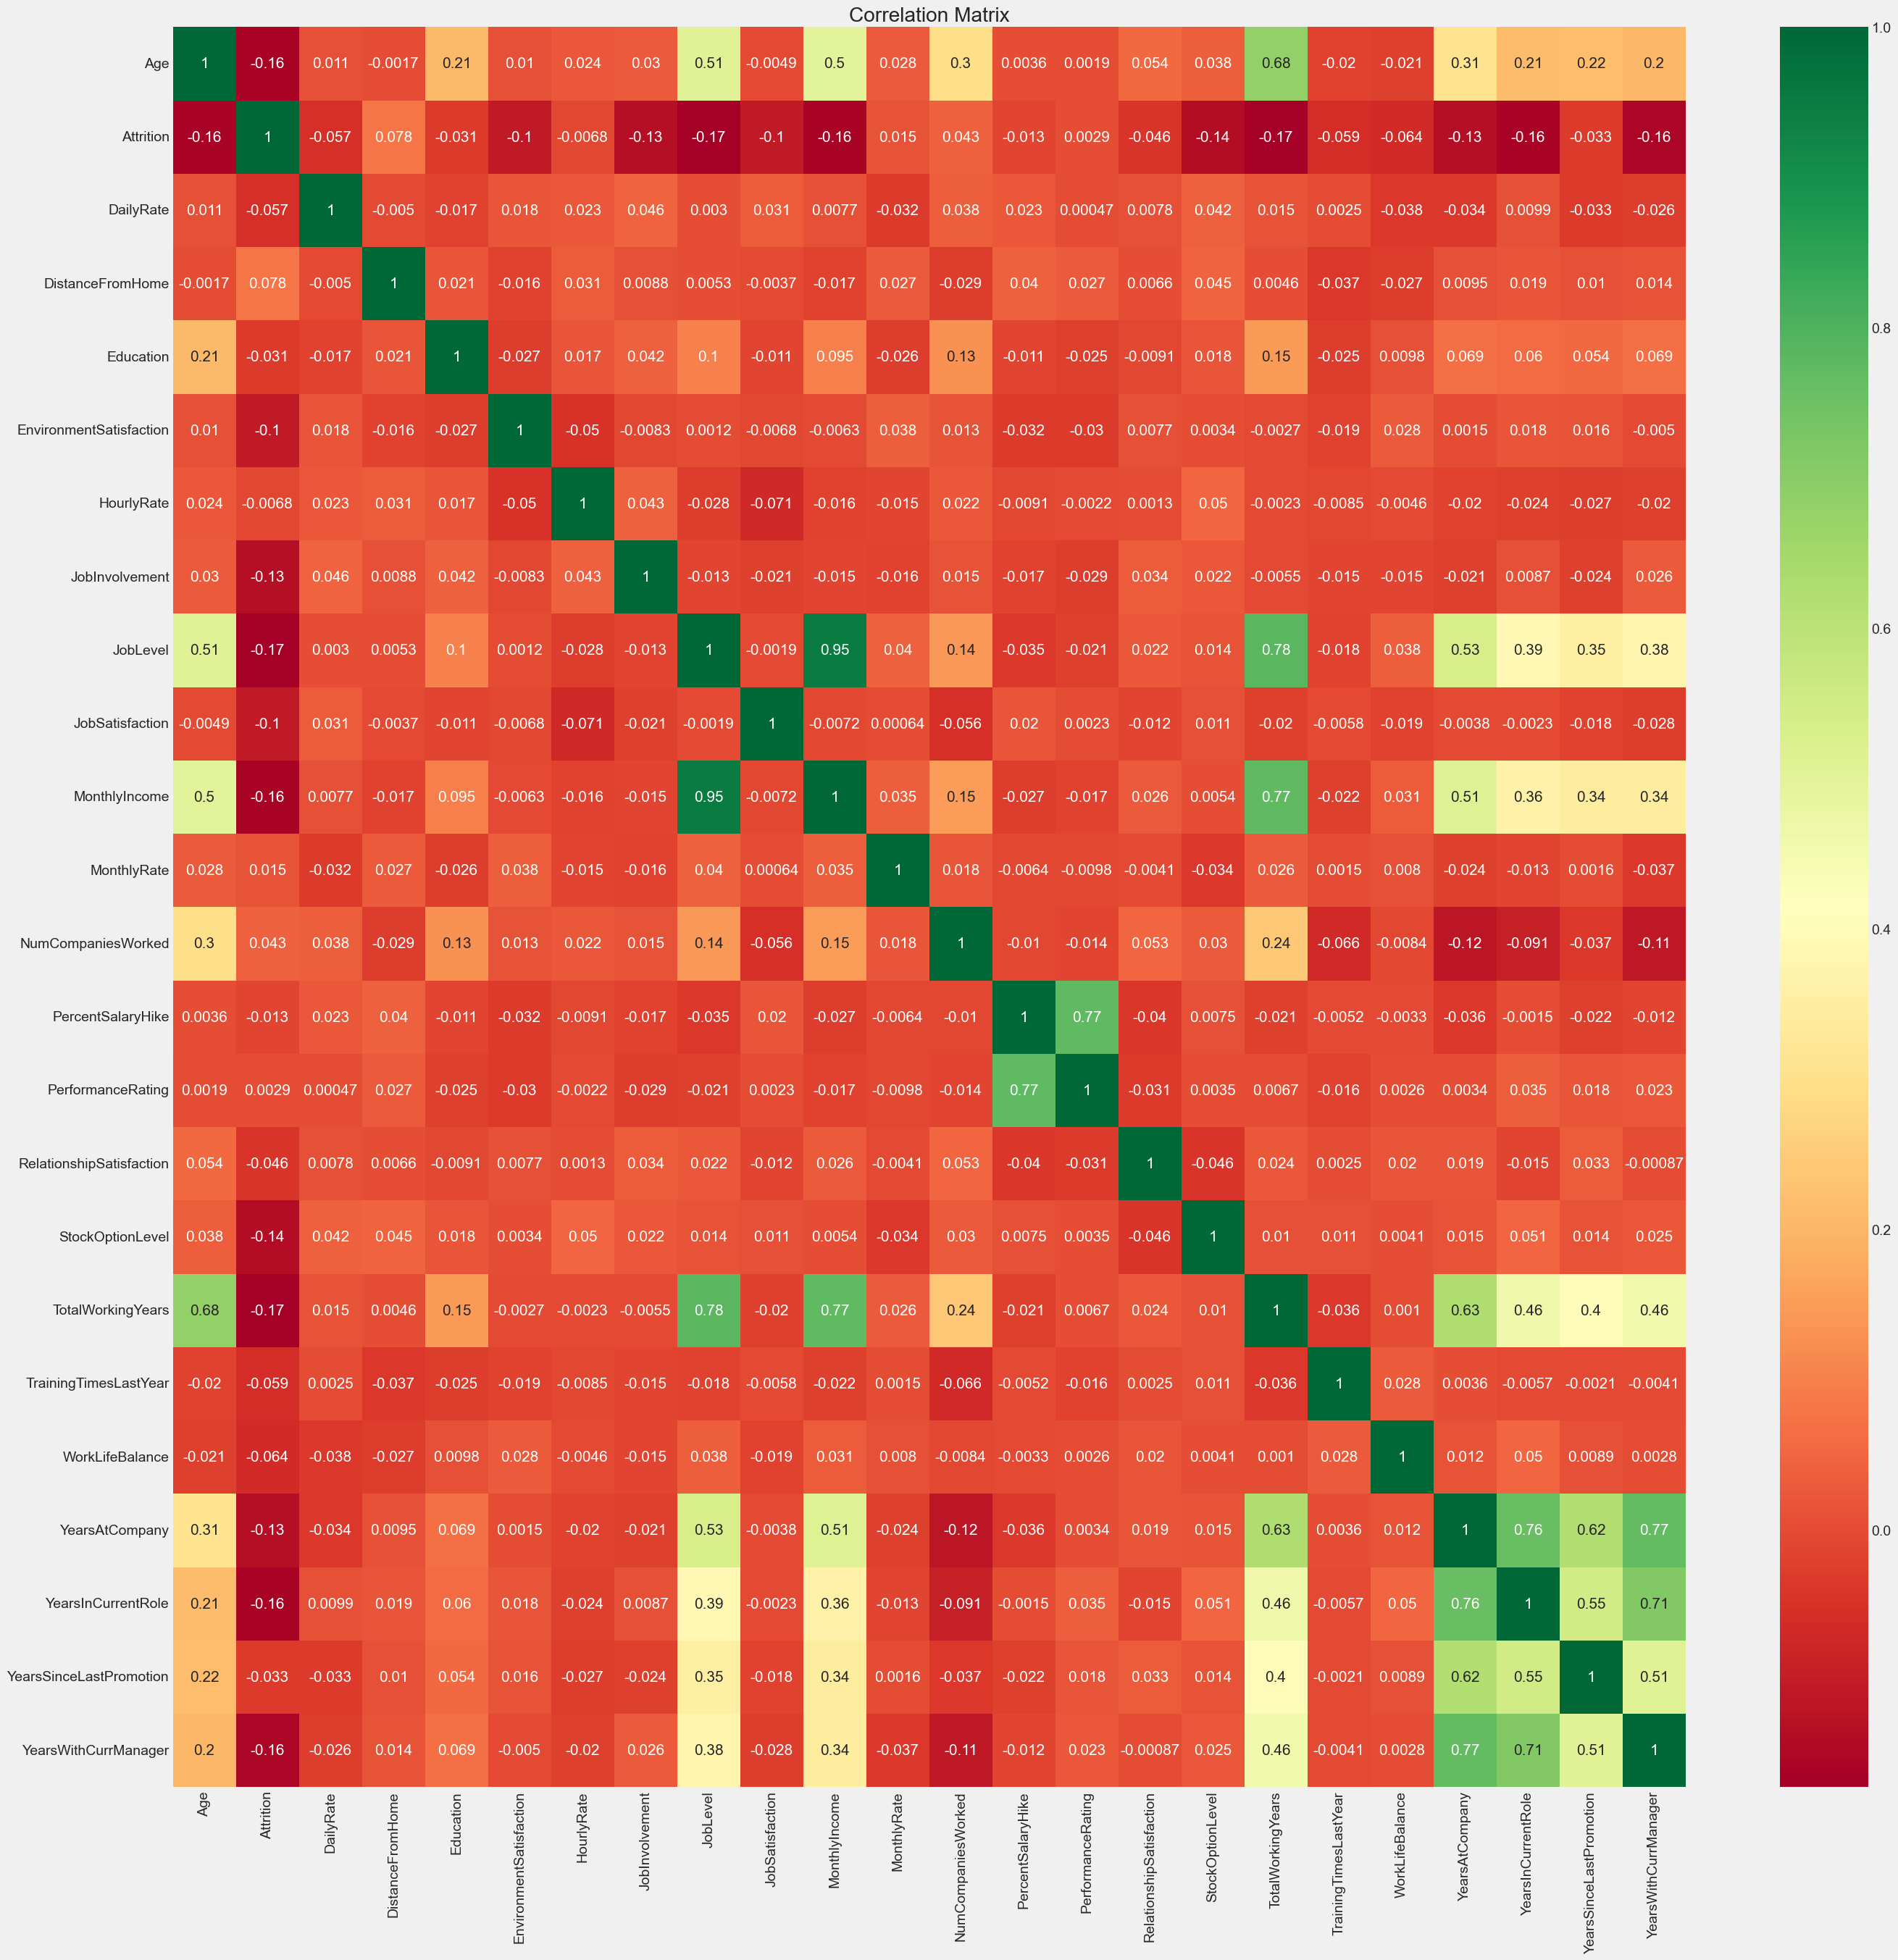

In [29]:
plt.figure(figsize=(30,30))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="RdYlGn", annot_kws={"size":15})
plt.title("Correlation Matrix")
plt.show()

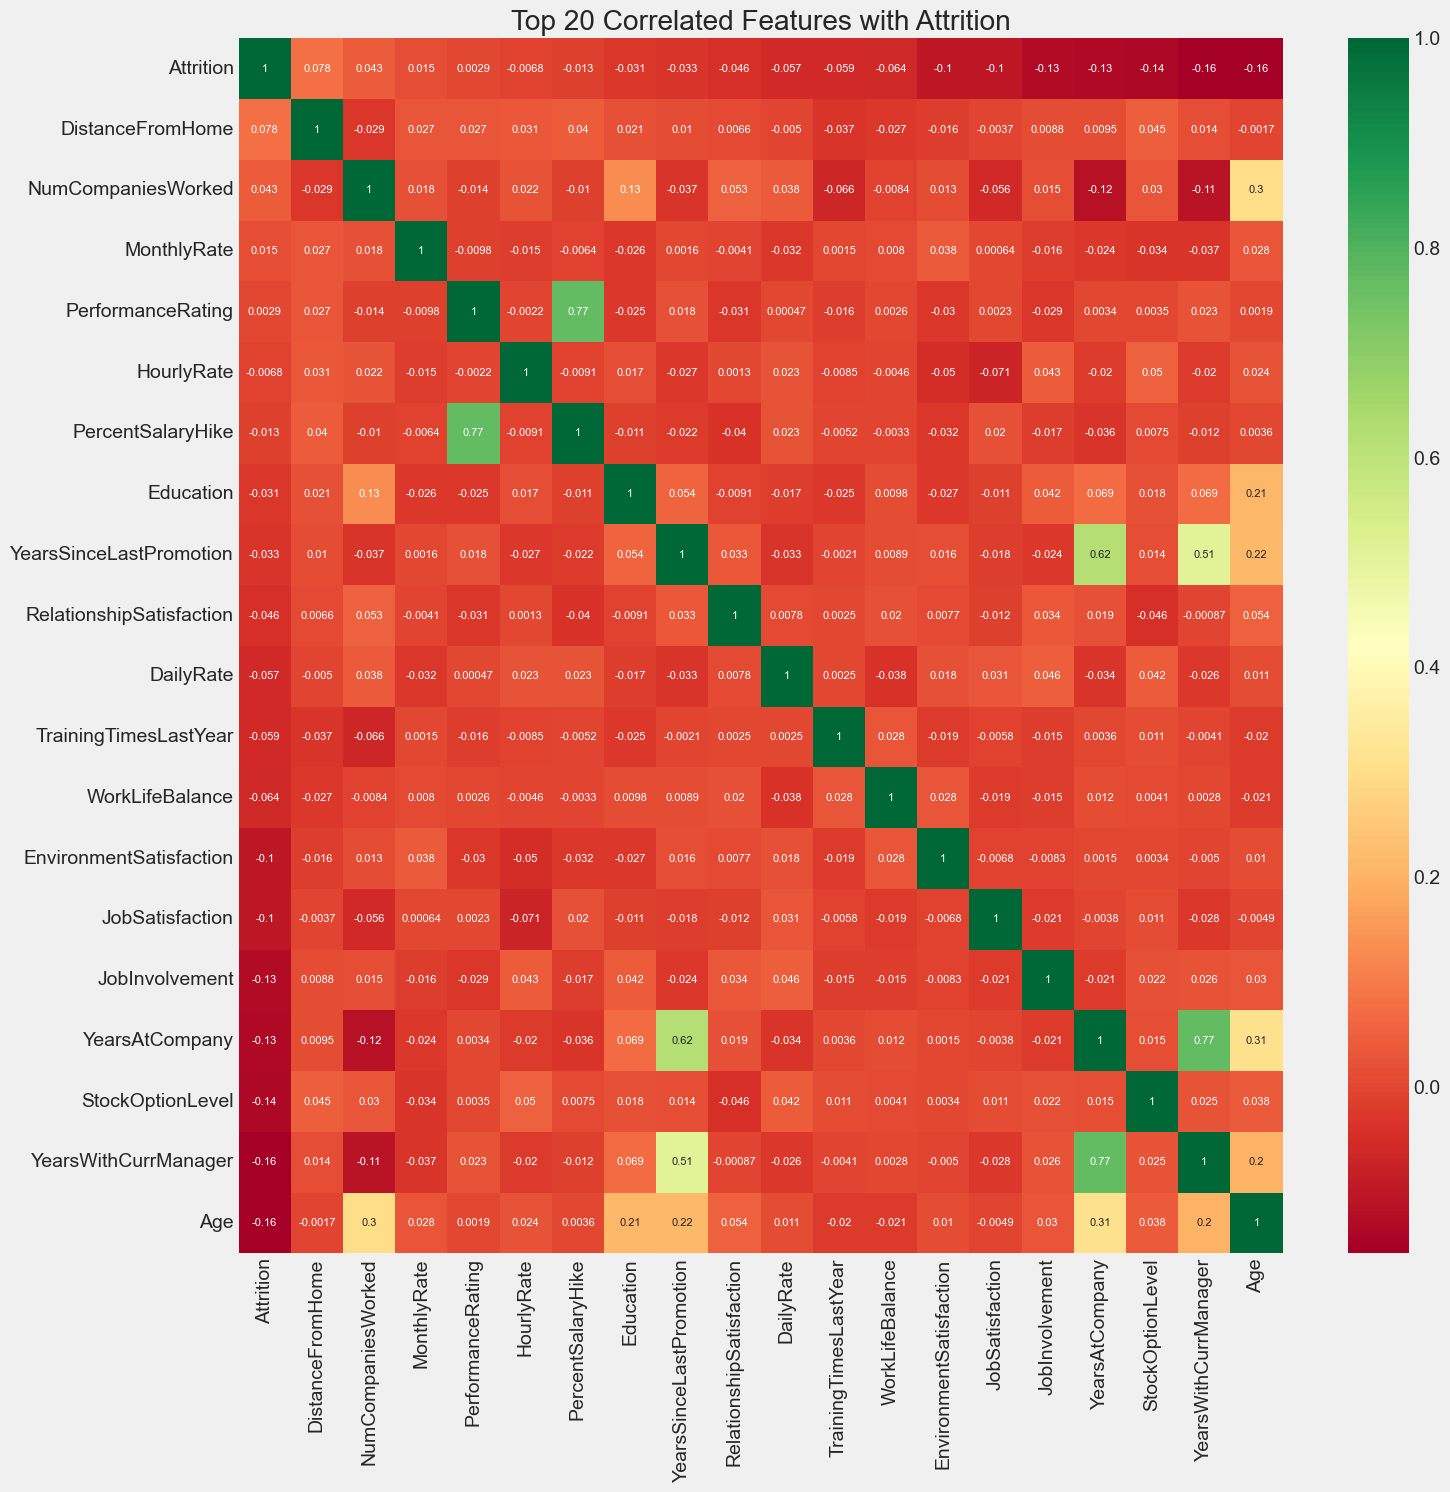

In [30]:
col = df.corr(numeric_only=True).nlargest(20, 'Attrition')['Attrition'].index
plt.figure(figsize=(15,15))
sns.heatmap(df[col].corr(numeric_only=True), annot=True, cmap="RdYlGn", annot_kws={"size":8})
plt.title("Top 20 Correlated Features with Attrition")
plt.show()

In [31]:
# 分析每个特征变量与目标变量（Attrition）的相关性强度
df.drop('Attrition', axis=1).corrwith(df['Attrition'], numeric_only=True).hvplot.barh()

:Bars   [index]   (0)

### Analysis of correlation results (sample analysis):
Monthly income is highly correlated with Job level.

Job level is highly correlated with total working hours.

Monthly income is highly correlated with total working hours.

Age is also positively correlated with the Total working hours.

Marital status and stock option level are negatively correlated

## Data Processing

In [32]:
# Transform categorical features into numerical features using dummy encoding 
dummy_col = [column for column in df.drop('Attrition', axis=1).columns if df[column].nunique() < 20]
data = pd.get_dummies(df, columns=dummy_col, drop_first=True, dtype='uint8')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Columns: 136 entries, Age to YearsWithCurrManager_17
dtypes: int64(9), uint8(127)
memory usage: 285.8 KB


In [33]:
print(data.shape)

# remove duplicate Features
data = data.T.drop_duplicates().T

# remove duplicate rows
data.drop_duplicates(inplace=True)

print(data.shape)

(1470, 136)
(1470, 136)


<Axes: title={'center': 'Feature Correlation with Attrition'}>

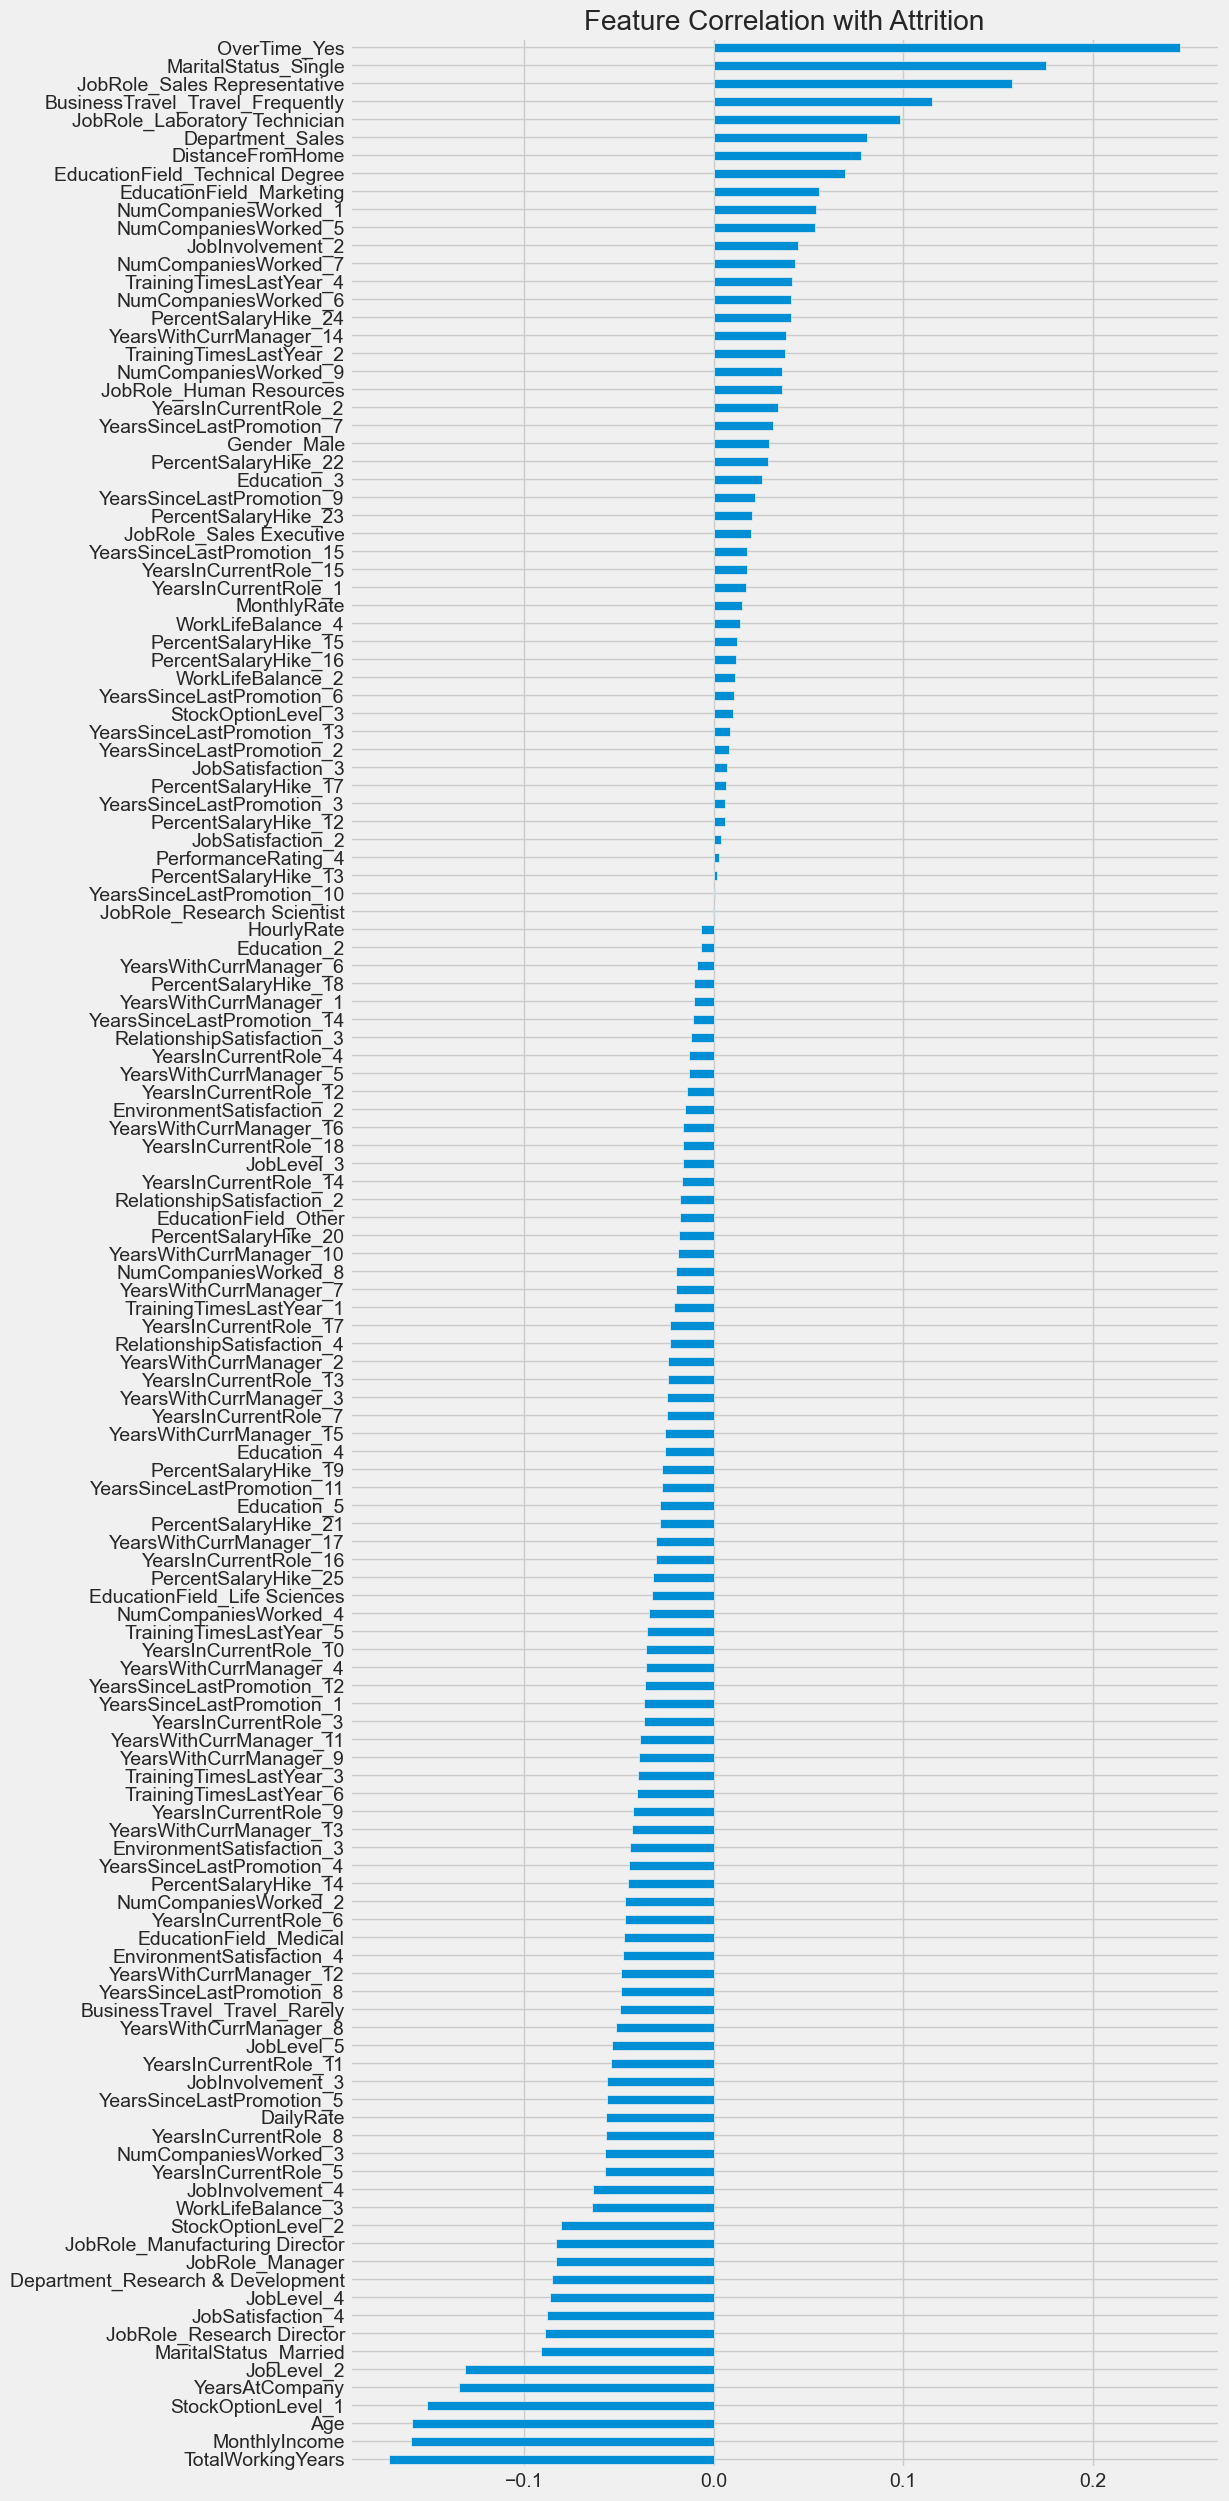

In [34]:
data.drop('Attrition', axis=1).corrwith(data.Attrition).sort_values().plot.barh(figsize=(10,30), title='Feature Correlation with Attrition')

In [35]:
feature_correlation = data.drop('Attrition', axis=1).corrwith(data.Attrition).sort_values()
model_col = feature_correlation[np.abs(feature_correlation) > 0.02].index
len(model_col)

92

## Applying machine learning algorithms

In [36]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

X = data.drop('Attrition', axis=1)
y = data['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)
X_std  = scaler.transform(X)

In [37]:
def feature_imp(df, model):
    fi = pd.DataFrame()
    fi["Feature"] = df.columns
    fi["Importance"] = model.feature_importances_
    fi = fi.sort_values(by="Importance", ascending=False).reset_index(drop=True)
    return fi.sort_values(by="Importance", ascending=False)

### What defines success?
We have an imbalanced data, so if we predict that all our employees will stay we'll have an accuracy of 84.01%.

In [38]:
y_test.value_counts()[0] / y_test.shape[0]

0.8401360544217688

In [39]:
stay = (y_train.value_counts()[0] / y_train.shape)[0]
leave = (y_train.value_counts()[1] / y_train.shape)[0]

print("===============TRAIN=================")
print(f"Staying Rate: {stay * 100:.2f}%")
print(f"Leaving Rate: {leave * 100 :.2f}%")

stay = (y_test.value_counts()[0] / y_test.shape)[0]
leave = (y_test.value_counts()[1] / y_test.shape)[0]

print("===============TEST=================")
print(f"Staying Rate: {stay * 100:.2f}%")
print(f"Leaving Rate: {leave * 100 :.2f}%")

===============TRAIN=================
Staying Rate: 83.84%
Leaving Rate: 16.16%
===============TEST=================
Staying Rate: 84.01%
Leaving Rate: 15.99%


In [40]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

def evaluate(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    print("Training Results: \n ==============")
    elf_report = pd.DataFrame(classification_report(y_train, y_train_pred, output_dict=True))
    print(f"Confusion_matrix:\n{confusion_matrix(y_train, y_train_pred)}")
    print(f"Accuracy Score:\n{accuracy_score(y_train, y_train_pred):.4f}")
    print(f"Classification Report:\n{elf_report}")

    print("\nTesting Results: \n ==============")
    test_report = pd.DataFrame(classification_report(y_test, y_test_pred, output_dict=True))
    print(f"Confusion_matrix:\n{confusion_matrix(y_test, y_test_pred)}")
    print(f"Accuracy Score:\n{accuracy_score(y_test, y_test_pred):.4f}")
    print(f"Classification Report:\n{test_report}")

### Logistic Regression

In [41]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(solver='liblinear', penalty='l1')
lr_clf.fit(X_train_std, y_train)

evaluate(lr_clf, X_train_std, y_train, X_test_std, y_test)

Training Results: 
Confusion_matrix:
[[964  22]
 [ 71 119]]
Accuracy Score:
0.9209
Classification Report:
               0      1  accuracy  macro avg  weighted avg
precision   0.93   0.84      0.92       0.89          0.92
recall      0.98   0.63      0.92       0.80          0.92
f1-score    0.95   0.72      0.92       0.84          0.92
support   986.00 190.00      0.92    1176.00       1176.00

Testing Results: 
Confusion_matrix:
[[230  17]
 [ 27  20]]
Accuracy Score:
0.8503
Classification Report:
               0     1  accuracy  macro avg  weighted avg
precision   0.89  0.54      0.85       0.72          0.84
recall      0.93  0.43      0.85       0.68          0.85
f1-score    0.91  0.48      0.85       0.69          0.84
support   247.00 47.00      0.85     294.00        294.00


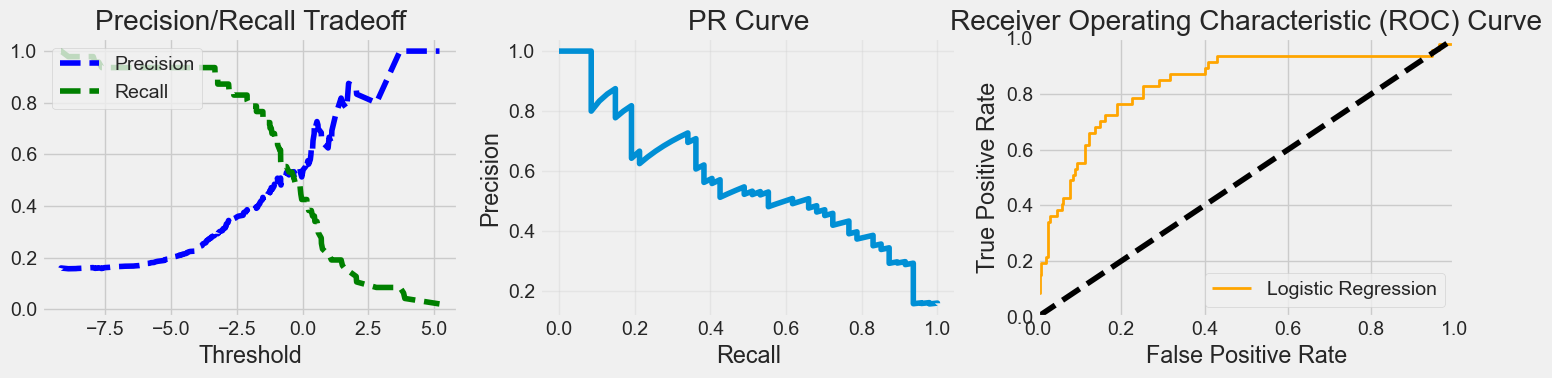

In [42]:
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score

def plot_precision_recall_vs_threshold(precision, recall, thresholds):
    plt.plot(thresholds, precision[:-1], "b--", label="Precision")
    plt.plot(thresholds, recall[:-1], "g--", label="Recall")
    plt.xlabel("Threshold")
    plt.title("Precision/Recall Tradeoff")
    plt.legend(loc = "upper left")

def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, color='orange', label=label)
    plt.plot([0, 1], [0, 1], "k--")
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()

# 计算数据
precision, recall, thresholds_pr = precision_recall_curve(y_test, lr_clf.decision_function(X_test_std))
fpr, tpr, thresholds_roc = roc_curve(y_test, lr_clf.decision_function(X_test_std))

# 画图
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plt.subplot(1, 3, 1)
plot_precision_recall_vs_threshold(precision, recall, thresholds_pr)

plt.subplot(1, 3, 2)
plt.plot(recall, precision)  # 注意：通常 x=Recall, y=Precision
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve")
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plot_roc_curve(fpr, tpr, label="Logistic Regression")

plt.tight_layout()
plt.show()

In [43]:
score_dict = {
    'Logistic Regression': {
        'Train' : roc_auc_score(y_train, lr_clf.predict(X_train_std)),
        'Test' : roc_auc_score(y_test, lr_clf.predict(X_test_std)),
    },
}

score_dict

{'Logistic Regression': {'Train': 0.802001708124266,
  'Test': 0.6783530019812214}}

### Random Forest Classifer

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, bootstrap=True)

rf_clf.fit(X_train, y_train)
evaluate(rf_clf, X_train, y_train, X_test, y_test)

Training Results: 
Confusion_matrix:
[[986   0]
 [  0 190]]
Accuracy Score:
1.0000
Classification Report:
               0      1  accuracy  macro avg  weighted avg
precision   1.00   1.00      1.00       1.00          1.00
recall      1.00   1.00      1.00       1.00          1.00
f1-score    1.00   1.00      1.00       1.00          1.00
support   986.00 190.00      1.00    1176.00       1176.00

Testing Results: 
Confusion_matrix:
[[241   6]
 [ 44   3]]
Accuracy Score:
0.8299
Classification Report:
               0     1  accuracy  macro avg  weighted avg
precision   0.85  0.33      0.83       0.59          0.76
recall      0.98  0.06      0.83       0.52          0.83
f1-score    0.91  0.11      0.83       0.51          0.78
support   247.00 47.00      0.83     294.00        294.00


In [47]:
param_grid = {
    'n_estimators': [100, 500, 900],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [2,3,5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf_clf = RandomForestClassifier(random_state=42)
search = GridSearchCV(estimator=rf_clf, param_grid=param_grid,
                      scoring='roc_auc', cv = 5, verbose=1, n_jobs=-1)
search.fit(X_train, y_train)

rf_clf = RandomForestClassifier(**search.best_params_, random_state=42)
rf_clf.fit(X_train, y_train)
evaluate(rf_clf, X_train, y_train, X_test, y_test)

Fitting 5 folds for each of 972 candidates, totalling 4860 fits
Training Results: 
Confusion_matrix:
[[986   0]
 [  3 187]]
Accuracy Score:
0.9974
Classification Report:
               0      1  accuracy  macro avg  weighted avg
precision   1.00   1.00      1.00       1.00          1.00
recall      1.00   0.98      1.00       0.99          1.00
f1-score    1.00   0.99      1.00       1.00          1.00
support   986.00 190.00      1.00    1176.00       1176.00

Testing Results: 
Confusion_matrix:
[[246   1]
 [ 44   3]]
Accuracy Score:
0.8469
Classification Report:
               0     1  accuracy  macro avg  weighted avg
precision   0.85  0.75      0.85       0.80          0.83
recall      1.00  0.06      0.85       0.53          0.85
f1-score    0.92  0.12      0.85       0.52          0.79
support   247.00 47.00      0.85     294.00        294.00


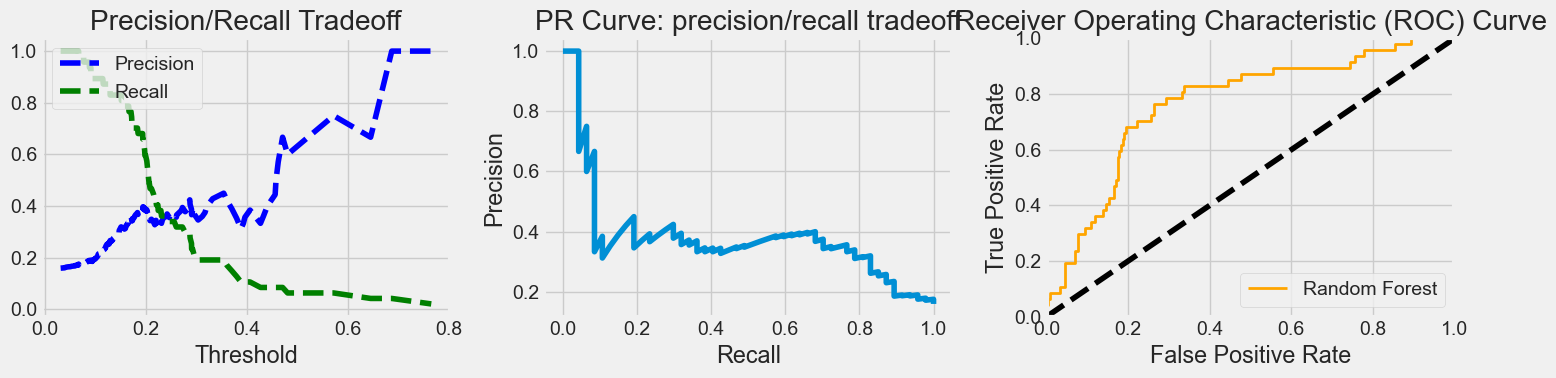

In [48]:
precision, recall, thresholds = precision_recall_curve(y_test, rf_clf.predict_proba(X_test)[:,1])
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plt.subplot(1,3,1)
plot_precision_recall_vs_threshold(precision, recall, thresholds)   

plt.subplot(1,3,2)
plt.plot(recall, precision)  # 注意：通常 x=Recall, y=Precision
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve: precision/recall tradeoff")

plt.subplot(1,3,3)
fpr, tpr, _ = roc_curve(y_test, rf_clf.predict_proba(X_test)[:,1])
plot_roc_curve(fpr, tpr, label="Random Forest")
plt.tight_layout()
plt.show()

In [50]:
score_dict['Random Forest'] = {
    'Train' : roc_auc_score(y_train, rf_clf.predict(X_train)),
    'Test' : roc_auc_score(y_test, rf_clf.predict(X_test)),
}

score_dict['Random Forest']

{'Train': 0.9921052631578947, 'Test': 0.5298906021190456}

<Axes: title={'center': 'Top 40 Feature Importance from Random Forest Classifier'}, ylabel='Feature'>

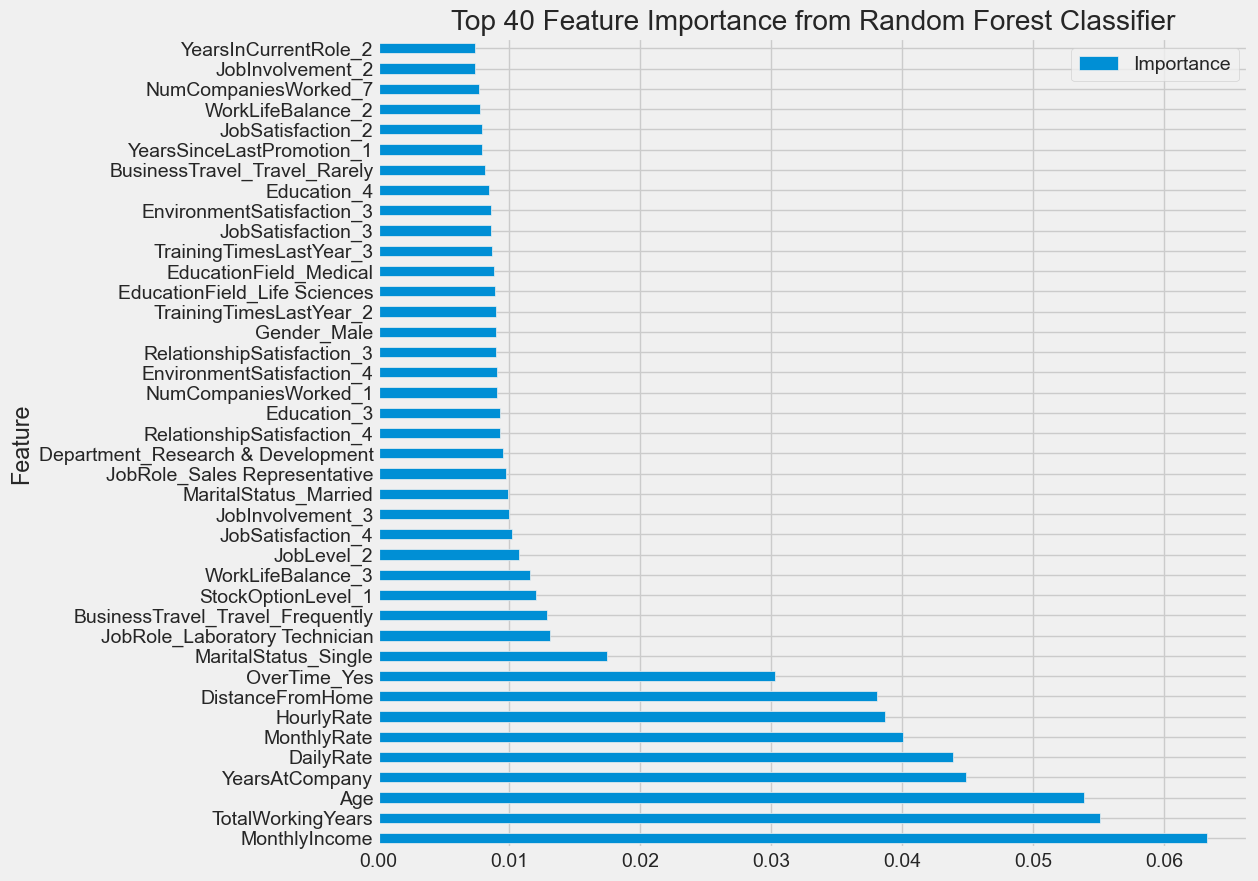

In [51]:
df = feature_imp(X, rf_clf)[:40]
df.set_index('Feature', inplace=True)
df.plot.barh(title='Top 40 Feature Importance from Random Forest Classifier', figsize=(10,10))

### Support Vector Machine

In [52]:
from sklearn.svm import SVC

svm_clf = SVC(kernel='linear')
svm_clf.fit(X_train_std, y_train)

evaluate(svm_clf, X_train_std, y_train, X_test_std, y_test)

Training Results: 
Confusion_matrix:
[[965  21]
 [ 53 137]]
Accuracy Score:
0.9371
Classification Report:
               0      1  accuracy  macro avg  weighted avg
precision   0.95   0.87      0.94       0.91          0.93
recall      0.98   0.72      0.94       0.85          0.94
f1-score    0.96   0.79      0.94       0.88          0.93
support   986.00 190.00      0.94    1176.00       1176.00

Testing Results: 
Confusion_matrix:
[[228  19]
 [ 26  21]]
Accuracy Score:
0.8469
Classification Report:
               0     1  accuracy  macro avg  weighted avg
precision   0.90  0.53      0.85       0.71          0.84
recall      0.92  0.45      0.85       0.68          0.85
f1-score    0.91  0.48      0.85       0.70          0.84
support   247.00 47.00      0.85     294.00        294.00


In [53]:
svm_clf = SVC(random_state=42)

param_grid = [
    {'C': [0.1, 1, 10, 100, 1000], 'kernel': ['linear']},
    {'C': [0.1, 1, 10, 100, 1000], 'kernel': ['rbf'], 'gamma': [0.001, 0.0001]}
]

search = GridSearchCV(svm_clf, param_grid, scoring='roc_auc', cv=3, verbose=1, refit=True)
search.fit(X_train_std, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


GridSearchCV(cv=3, estimator=SVC(random_state=42),
             param_grid=[{'C': [0.1, 1, 10, 100, 1000], 'kernel': ['linear']},
                         {'C': [0.1, 1, 10, 100, 1000],
                          'gamma': [0.001, 0.0001], 'kernel': ['rbf']}],
             scoring='roc_auc', verbose=1)

In [54]:
print(f"Best parameters: {search.best_params_}")
print(f"Best CV score: {search.best_score_:.4f}")

# Create and train the optimal SVM classifier
svm_clf_optimal = SVC(**search.best_params_, probability=True)
svm_clf_optimal.fit(X_train_std, y_train)

evaluate(svm_clf_optimal, X_train_std, y_train, X_test_std, y_test)

Best parameters: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Best CV score: 0.8277
Training Results: 
Confusion_matrix:
[[985   1]
 [  9 181]]
Accuracy Score:
0.9915
Classification Report:
               0      1  accuracy  macro avg  weighted avg
precision   0.99   0.99      0.99       0.99          0.99
recall      1.00   0.95      0.99       0.98          0.99
f1-score    0.99   0.97      0.99       0.98          0.99
support   986.00 190.00      0.99    1176.00       1176.00

Testing Results: 
Confusion_matrix:
[[234  13]
 [ 31  16]]
Accuracy Score:
0.8503
Classification Report:
               0     1  accuracy  macro avg  weighted avg
precision   0.88  0.55      0.85       0.72          0.83
recall      0.95  0.34      0.85       0.64          0.85
f1-score    0.91  0.42      0.85       0.67          0.84
support   247.00 47.00      0.85     294.00        294.00


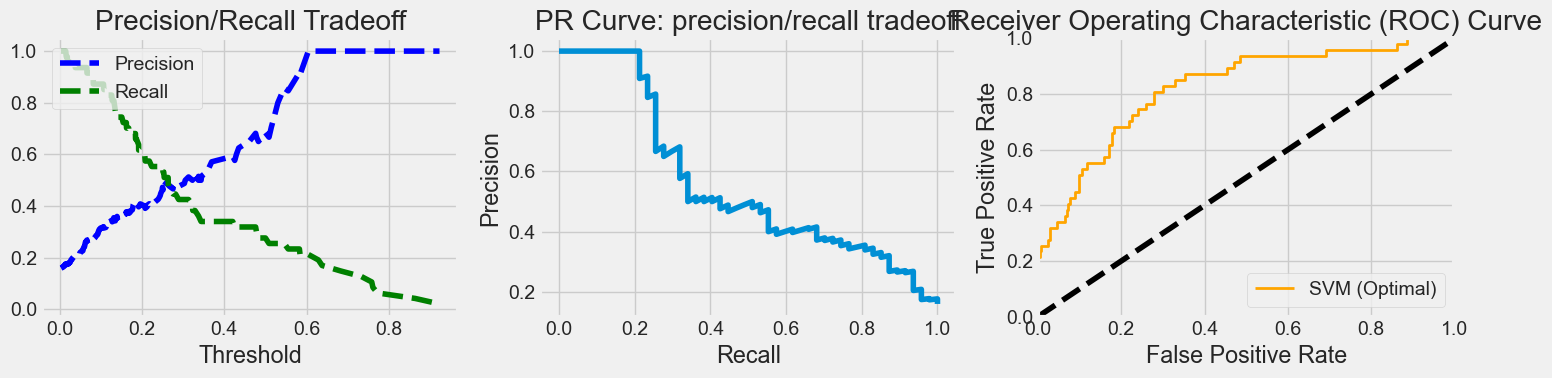

In [55]:
precision, recall, thresholds = precision_recall_curve(y_test, svm_clf_optimal.predict_proba(X_test_std)[:,1])
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plt.subplot(1,3,1)
plot_precision_recall_vs_threshold(precision, recall, thresholds)   

plt.subplot(1,3,2)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve: precision/recall tradeoff")

plt.subplot(1,3,3)
fpr, tpr, _ = roc_curve(y_test, svm_clf_optimal.predict_proba(X_test_std)[:,1])
plot_roc_curve(fpr, tpr, label="SVM (Optimal)")
plt.tight_layout()
plt.show()

In [56]:
score_dict['SVM (Optimal)'] = {
    'Train' : roc_auc_score(y_train, svm_clf_optimal.predict_proba(X_train_std)[:,1]),
    'Test' : roc_auc_score(y_test, svm_clf_optimal.predict_proba(X_test_std)[:,1]),
}

score_dict['SVM (Optimal)']

{'Train': 0.9961994235080602, 'Test': 0.8214316478594195}

### XGBoost Classifier

In [57]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier()
xgb_clf.fit(X_train, y_train)
evaluate(xgb_clf, X_train, y_train, X_test, y_test)

Training Results: 
Confusion_matrix:
[[986   0]
 [  0 190]]
Accuracy Score:
1.0000
Classification Report:
               0      1  accuracy  macro avg  weighted avg
precision   1.00   1.00      1.00       1.00          1.00
recall      1.00   1.00      1.00       1.00          1.00
f1-score    1.00   1.00      1.00       1.00          1.00
support   986.00 190.00      1.00    1176.00       1176.00

Testing Results: 
Confusion_matrix:
[[239   8]
 [ 38   9]]
Accuracy Score:
0.8435
Classification Report:
               0     1  accuracy  macro avg  weighted avg
precision   0.86  0.53      0.84       0.70          0.81
recall      0.97  0.19      0.84       0.58          0.84
f1-score    0.91  0.28      0.84       0.60          0.81
support   247.00 47.00      0.84     294.00        294.00


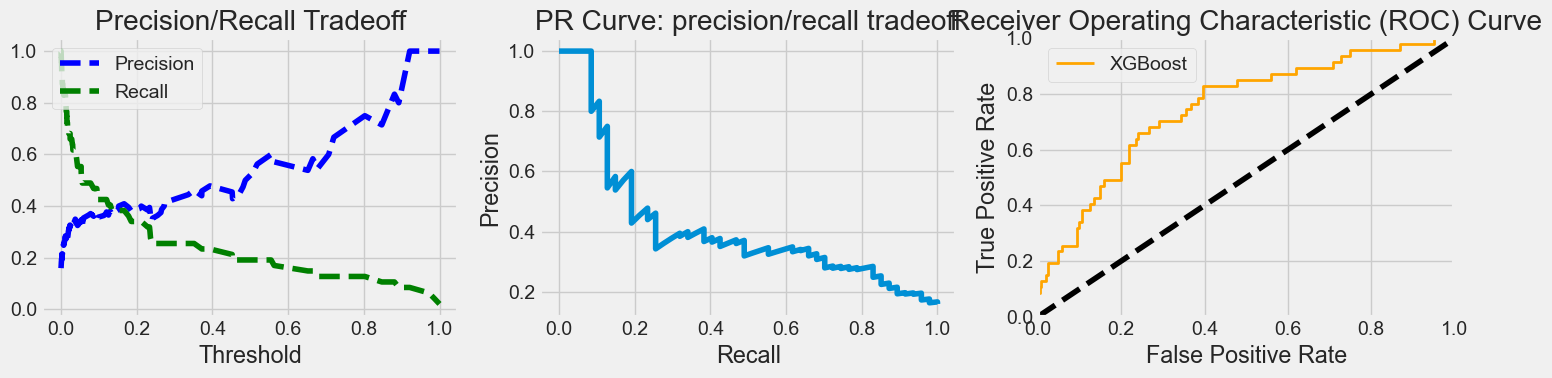

In [58]:
precision, recall, thresholds = precision_recall_curve(y_test, xgb_clf.predict_proba(X_test)[:,1])
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plt.subplot(1,3,1)
plot_precision_recall_vs_threshold(precision, recall, thresholds) 

plt.subplot(1,3,2)
plt.plot(recall, precision)  # 注意：通常 x=Recall, y=Precision
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve: precision/recall tradeoff")    

plt.subplot(1,3,3)
fpr, tpr, _ = roc_curve(y_test, xgb_clf.predict_proba(X_test)[:,1])
plot_roc_curve(fpr, tpr, label="XGBoost")

plt.tight_layout()
plt.show()

In [59]:
score_dict['XGBoost'] = {
    'Train' : roc_auc_score(y_train, xgb_clf.predict_proba(X_train)[:,1]),
    'Test' : roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:,1]),
}

score_dict['XGBoost']

{'Train': 1.0, 'Test': 0.7503660952709106}

<Axes: title={'center': 'Top 40 Feature Importance from XGBoost Classifier'}, ylabel='Feature'>

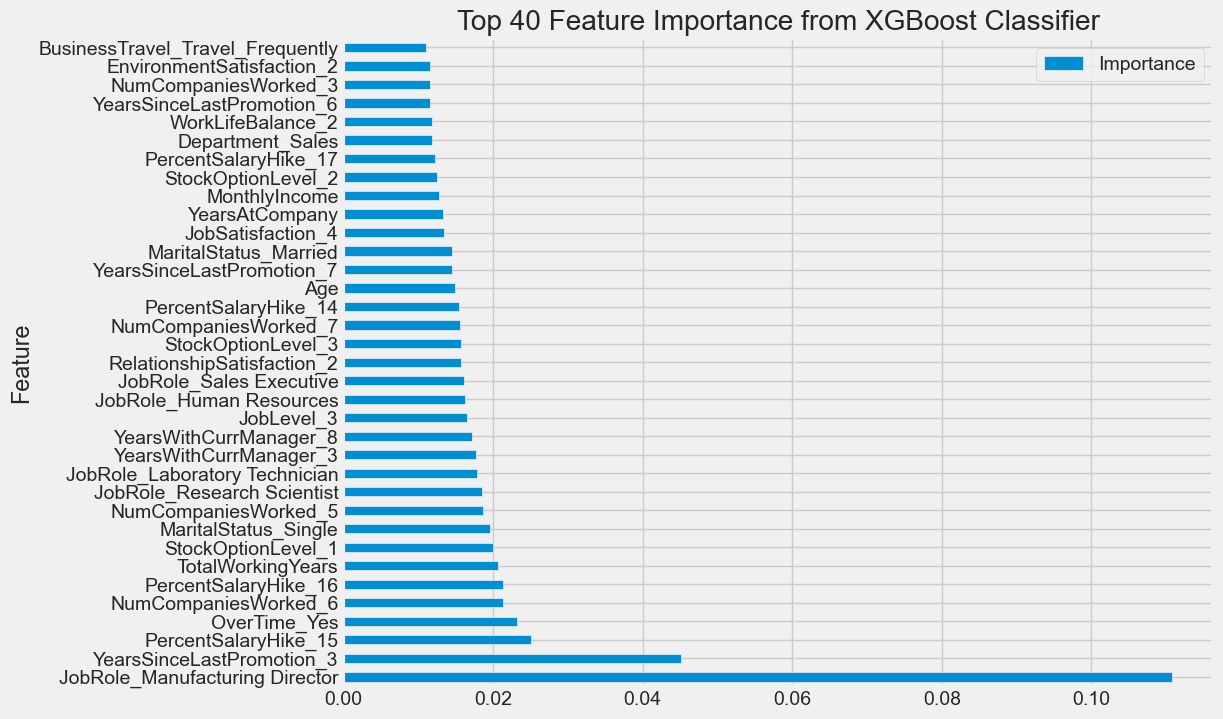

In [ ]:
df = feature_imp(X, xgb_clf)[:35]
df.set_index('Feature', inplace=True)
df.plot.barh(title='Top 35 Feature Importance from XGBoost Classifier', figsize=(10,8))

### LightGBM

In [65]:
from lightgbm import LGBMClassifier
lgbm_clf = LGBMClassifier()
lgbm_clf.fit(X_train, y_train)
evaluate(lgbm_clf, X_train, y_train, X_test, y_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 190, number of negative: 986
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000521 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1184
[LightGBM] [Info] Number of data points in the train set: 1176, number of used features: 111
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.161565 -> initscore=-1.646632
[LightGBM] [Info] Start training from score -1.646632
Training Results: 
Confusion_matrix:
[[986   0]
 [  0 190]]
Accuracy Score:
1.0000
Classification Report:
               0      1  accuracy  macro avg  weighted avg
precision   1.00   1.00      1.00       1.00          1.00
recall      1.00   1.00      1.00       1.00          1.00
f1-score    1.00   1.00      1.00       1.00          1.00
support   986.00 190.00 

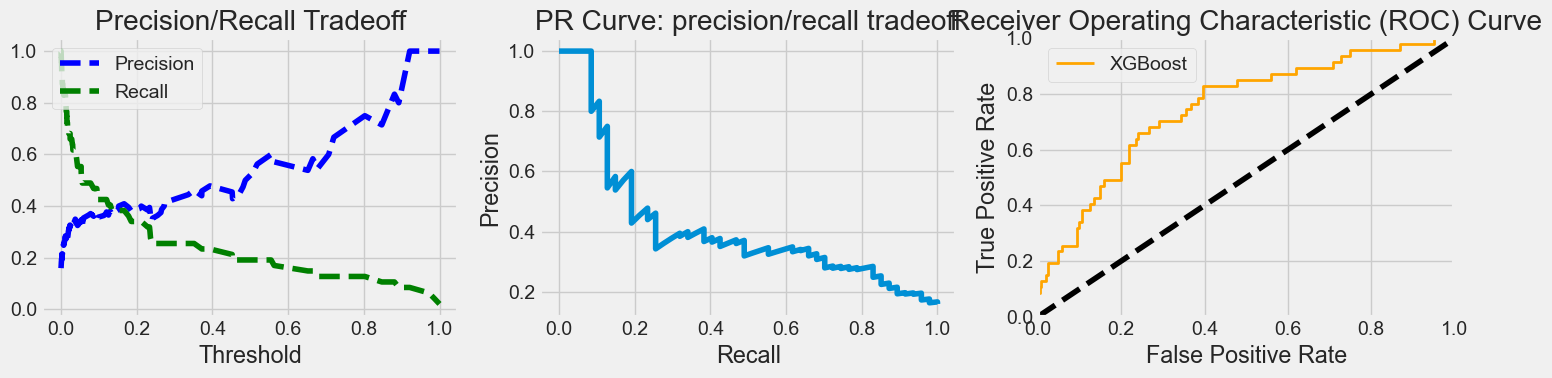

In [66]:
precision, recall, thresholds = precision_recall_curve(y_test, xgb_clf.predict_proba(X_test)[:,1])
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plt.subplot(1,3,1)
plot_precision_recall_vs_threshold(precision, recall, thresholds)
plt.subplot(1,3,2)
plt.plot(recall, precision)  # 注意：通常 x=Recall, y=Precision
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve: precision/recall tradeoff")
plt.subplot(1,3,3)
fpr, tpr, _ = roc_curve(y_test, xgb_clf.predict_proba(X_test)[:,1])
plot_roc_curve(fpr, tpr, label="XGBoost")
plt.tight_layout()
plt.show()

In [67]:
score_dict['XGBoost'] = {
    'Train' : roc_auc_score(y_train, xgb_clf.predict_proba(X_train)[:,1]),
    'Test' : roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:,1]),
} 
score_dict['XGBoost']

{'Train': 1.0, 'Test': 0.7503660952709106}

### CatBoost

In [69]:
from catboost import CatBoostClassifier
cat_clf = CatBoostClassifier(verbose=0)
cat_clf.fit(X_train, y_train)
evaluate(cat_clf, X_train, y_train, X_test, y_test)

Training Results: 
Confusion_matrix:
[[986   0]
 [ 18 172]]
Accuracy Score:
0.9847
Classification Report:
               0      1  accuracy  macro avg  weighted avg
precision   0.98   1.00      0.98       0.99          0.98
recall      1.00   0.91      0.98       0.95          0.98
f1-score    0.99   0.95      0.98       0.97          0.98
support   986.00 190.00      0.98    1176.00       1176.00

Testing Results: 
Confusion_matrix:
[[243   4]
 [ 38   9]]
Accuracy Score:
0.8571
Classification Report:
               0     1  accuracy  macro avg  weighted avg
precision   0.86  0.69      0.86       0.78          0.84
recall      0.98  0.19      0.86       0.59          0.86
f1-score    0.92  0.30      0.86       0.61          0.82
support   247.00 47.00      0.86     294.00        294.00


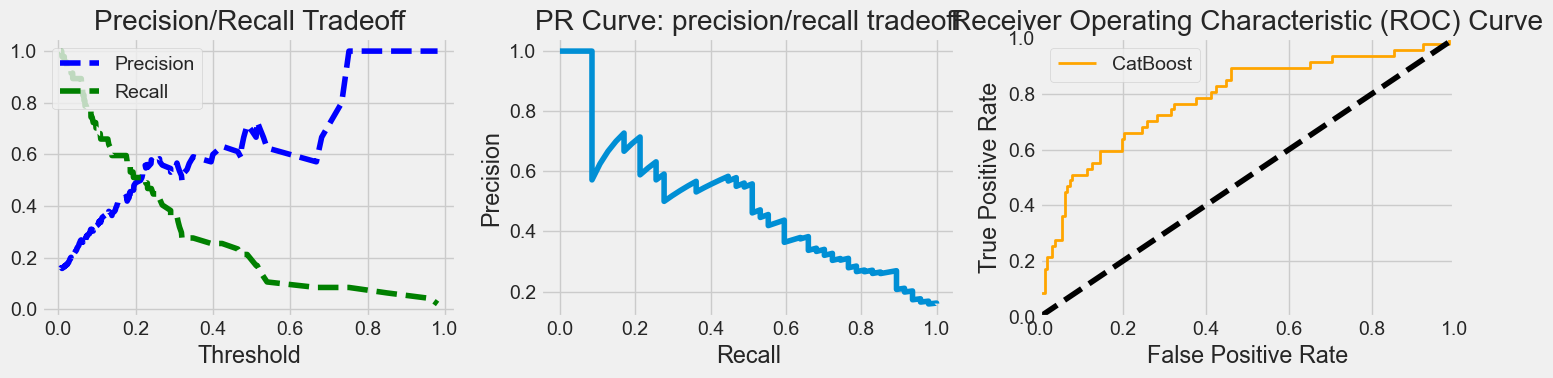

In [70]:
precision, recall, thresholds = precision_recall_curve(y_test, cat_clf.predict_proba(X_test)[:,1])
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plt.subplot(1,3,1)
plot_precision_recall_vs_threshold(precision, recall, thresholds) 
plt.subplot(1,3,2)
plt.plot(recall, precision)  # 注意：通常 x=Recall, y=Precision
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve: precision/recall tradeoff")
plt.subplot(1,3,3)
fpr, tpr, _ = roc_curve(y_test, cat_clf.predict_proba(X_test)[:,1])
plot_roc_curve(fpr, tpr, label="CatBoost")
plt.tight_layout()
plt.show()

In [71]:
score_dict['XGBoost'] = {
    'Train' : roc_auc_score(y_train, xgb_clf.predict_proba(X_train)[:,1]),
    'Test' : roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:,1]),
} 
score_dict['XGBoost']

{'Train': 1.0, 'Test': 0.7503660952709106}

### AdaBoost

In [72]:
from sklearn.ensemble import AdaBoostClassifier
adb_clf = AdaBoostClassifier()
adb_clf.fit(X_train, y_train)
evaluate(adb_clf, X_train, y_train, X_test, y_test)

Training Results: 
Confusion_matrix:
[[969  17]
 [106  84]]
Accuracy Score:
0.8954
Classification Report:
               0      1  accuracy  macro avg  weighted avg
precision   0.90   0.83      0.90       0.87          0.89
recall      0.98   0.44      0.90       0.71          0.90
f1-score    0.94   0.58      0.90       0.76          0.88
support   986.00 190.00      0.90    1176.00       1176.00

Testing Results: 
Confusion_matrix:
[[236  11]
 [ 36  11]]
Accuracy Score:
0.8401
Classification Report:
               0     1  accuracy  macro avg  weighted avg
precision   0.87  0.50      0.84       0.68          0.81
recall      0.96  0.23      0.84       0.59          0.84
f1-score    0.91  0.32      0.84       0.61          0.82
support   247.00 47.00      0.84     294.00        294.00


/Users/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


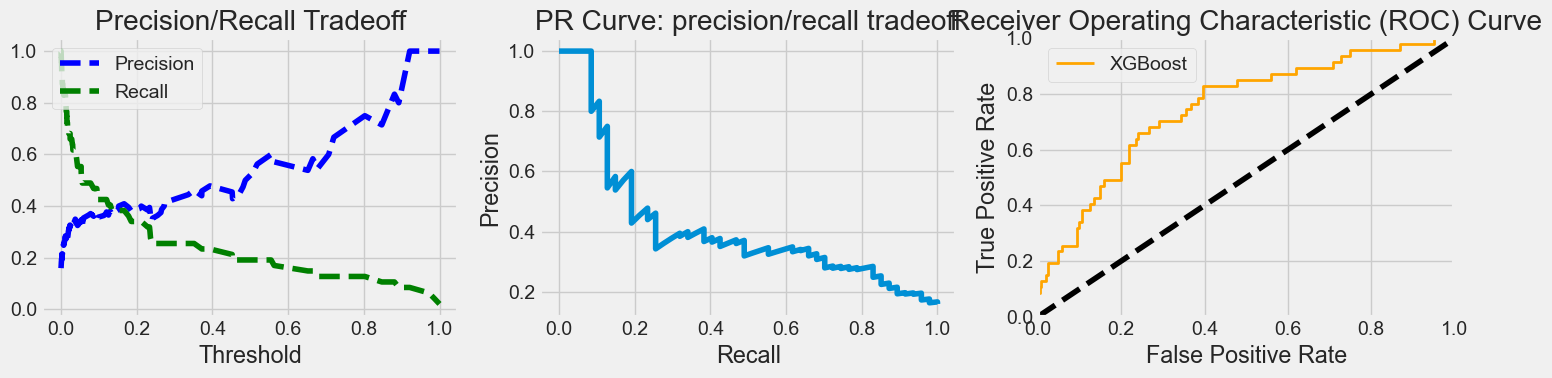

In [73]:
precision, recall, thresholds = precision_recall_curve(y_test, xgb_clf.predict_proba(X_test)[:,1])
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plt.subplot(1,3,1)
plot_precision_recall_vs_threshold(precision, recall, thresholds)
plt.subplot(1,3,2)
plt.plot(recall, precision)  # 注意：通常 x=Recall, y=Precision
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve: precision/recall tradeoff")
plt.subplot(1,3,3)
fpr, tpr, _ = roc_curve(y_test, xgb_clf.predict_proba(X_test)[:,1])
plot_roc_curve(fpr, tpr, label="XGBoost")
plt.tight_layout()
plt.show()

In [74]:
score_dict['AdaBoost'] = {
    'Train' : roc_auc_score(y_train, adb_clf.predict_proba(X_train)[:,1]),
    'Test' : roc_auc_score(y_test, adb_clf.predict_proba(X_test)[:,1]),
}
score_dict['AdaBoost']

{'Train': 0.9107398313227288, 'Test': 0.7725902317167714}

# Comparing Models Performance

In [78]:
ml_model = {
    'Random Forest': rf_clf,
    'XGBoost': xgb_clf, 
    'Logistic Regression': lr_clf,
    'SVM (Optimal)': svm_clf_optimal,
    'LightGBM': lgbm_clf,
    'CatBoost': cat_clf, 
    'AdaBoost': adb_clf
}

for model in ml_model:
    print(f"{model.upper():{20}} roc_auc_score : {roc_auc_score(y_test, ml_model[model].predict_proba(X_test)[:,1]):.4f}")

RANDOM FOREST        roc_auc_score : 0.7671
XGBOOST              roc_auc_score : 0.7504
LOGISTIC REGRESSION  roc_auc_score : 0.5454
SVM (OPTIMAL)        roc_auc_score : 0.5000
LIGHTGBM             roc_auc_score : 0.7928
CATBOOST             roc_auc_score : 0.7849
ADABOOST             roc_auc_score : 0.7726


/Users/anaconda3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/anaconda3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


In [86]:
score_df = pd.DataFrame(score_dict)

score_df.hvplot.barh(title='Model ROC AUC Score Comparison', figsize=(10,6))

:Bars   [index,Variable]   (value)